Introduction


The project is based on the  dataset “Wearable Health Devices Performance Analysis”:

The dataset contains performance evaluations of wearable health devices collected between June 1, 2025 and June 26, 2025. It includes a total of 2,375 observations (rows) and 17 variables (17 columns).

The dataset covers major wearable technology brands such as Apple, Samsung, Garmin, Fitbit, Huawei, Amazfit, WHOOP, Oura, Polar, and Withings.

Devices are categorized into types such as smartwatches, fitness trackers, smart rings, fitness bands, and sports watches. The dataset covers the device technical specifications, performance metrics and user satisfaction ratings.

The variables in the dataset include:

- Product information:
test date, device name, brand, model, category.

- Market information:
price in USD and app ecosystem support (iOS, Android, Cross-platform)

- Device specifications:
battery life hours, number of sensors, connectivity features (Bluetooth, WiFi, NFC, LTE), and water resistance features (e.g., IP68, 5ATM).

- Performance metrics:
heart rate accuracy (%), step count accuracy (%), sleep tracking accuracy (%), GPS accuracy (meters)

- User perception: user satisfaction rating (1–10 scale)

- Overall evaluation: performance score (0–100), which represents a composite measure of device performance.

The aim of my project is to examine how device characteristics and price relate to both objective performance and subjective user satisfaction in wearable health devices.

More specifically, I will address several research questions:

- To what extent does device price predict overall performance score?
- Which device features (e.g., battery life, accuracy metrics, number of sensors) influence user satisfaction ratings?

Although the dataset is synthetic, it provides a useful basis for practicing statistical analysis and exploring patterns relevant to digital health wearables. In particular, this project connects to my Master's thesis on digital health/wellness wearable technologies, where I examine user perceptions (perceived value) of wearable devices through a survey experiment.

I will start with data cleaning and preprocessing (e.g., handling missing values, converting data types, etc.). Next, I will conduct exploratory data analysis (EDA) to understand the distribution of key variables (e.g., price, performance score, user satisfaction) and identify patterns across brands and device categories.

Notebook Documentation

This notebook was created using Python 3 and Jupyter Notebook.

How to use

1. It requires setting several libraries:
- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- requests
2. Download the dataset from Kaggle: https://www.kaggle.com/datasets/pratyushpuri/wearable-health-devices-performance-analysis
3. Place the CSV file in the same folder as the notebook.
4. Run all notebook cells sequentially


The notebook exports:
- raw dataset CSV
- cleaned dataset CSV
- model results CSV

In [39]:
# connecting to the database file
import pandas as pd

df_wearables = pd.read_csv("wearable_health_devices_performance_upto_26june2025.csv")

# loading
df_wearables.head(10)

# Export a pandas DataFrame to CSV
# without reconnecting to the original source

df_wearables.to_csv("raw_wearables_data.csv", index=False)
print("DataFrame exported to raw_wearables_data.csv")

DataFrame exported to raw_wearables_data.csv


In [40]:
# Alternative loading method using exported raw dataset

# import pandas as pd
# df_wearables = pd.read_csv("raw_wearables_data.csv")
# df_wearables.head()

In [41]:
# Data Cleaning and Transformation
import numpy as np

# Check dataset structure - column names
df_wearables.info()

#Check summary statistics for numeric columns
df_wearables.describe()

# Remove duplicate rows
df_wearables = df_wearables.drop_duplicates()

# Remove extra spaces from column names
df_wearables.columns = df_wearables.columns.str.strip()

# Check missing values per column
df_wearables.isnull().sum()

# Convert test date column to datetime format
df_wearables["Test_Date"] = pd.to_datetime(
    df_wearables["Test_Date"]
)

# Create a new variable:
# convert battery life from hours to days

df_wearables["Battery_Life_Days"] = (
    df_wearables["Battery_Life_Hours"] / 24
)


# Check cleaned dataset
df_wearables.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2375 entries, 0 to 2374
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Test_Date                        2375 non-null   object 
 1   Device_Name                      2375 non-null   object 
 2   Brand                            2375 non-null   object 
 3   Model                            2375 non-null   object 
 4   Category                         2375 non-null   object 
 5   Price_USD                        2375 non-null   float64
 6   Battery_Life_Hours               2375 non-null   float64
 7   Heart_Rate_Accuracy_Percent      2375 non-null   float64
 8   Step_Count_Accuracy_Percent      2375 non-null   float64
 9   Sleep_Tracking_Accuracy_Percent  2375 non-null   float64
 10  Water_Resistance_Rating          2375 non-null   object 
 11  User_Satisfaction_Rating         2375 non-null   float64
 12  GPS_Accuracy_Meters 

,Test_Date,Device_Name,Brand,Model,Category,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,Water_Resistance_Rating,User_Satisfaction_Rating,GPS_Accuracy_Meters,Connectivity_Features,Health_Sensors_Count,App_Ecosystem_Support,Performance_Score,Battery_Life_Days
0,2025-06-01,Fitbit Inspire 4,Fitbit,Inspire 4,Fitness Tracker,141.74,129.9,89.69,93.03,78.91,3ATM,6.5,NaN,"Bluetooth, WiFi",5,Cross-platform,68.4,5.412500
1,2025-06-01,Apple Watch SE 3,Apple,Watch SE 3,Smartwatch,834.64,26.5,95.92,98.20,79.76,IP68,8.3,4.9,"WiFi, Bluetooth, NFC",8,iOS,60.1,1.104167
2,2025-06-01,Fitbit Versa 4,Fitbit,Versa 4,Sports Watch,145.34,161.2,92.24,96.81,74.49,IPX8,6.0,1.7,Bluetooth,7,Cross-platform,59.3,6.716667
3,2025-06-01,Polar Vantage V3,Polar,Vantage V3,Smartwatch,349.53,69.4,96.77,95.56,78.06,IP68,8.0,3.2,"WiFi, Bluetooth, NFC, LTE",12,Cross-platform,61.0,2.891667
4,2025-06-01,Samsung Galaxy Watch FE,Samsung,Galaxy Watch FE,Smartwatch,502.43,39.7,92.27,98.15,75.23,IPX8,8.3,1.6,"WiFi, Bluetooth, NFC, LTE",14,Android/iOS,61.2,1.654167


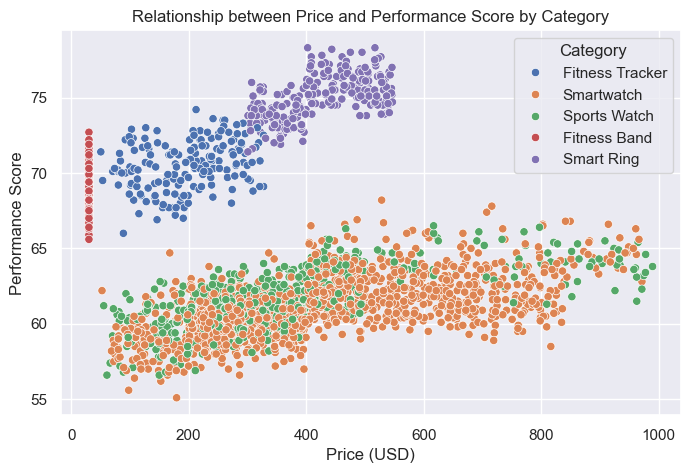

In [42]:
# scatterplot visualisation

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme() 

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_wearables, x="Price_USD", y="Performance_Score", hue="Category")

plt.title("Relationship between Price and Performance Score by Category")
plt.xlabel("Price (USD)")



plt.ylabel("Performance Score")
plt.show()

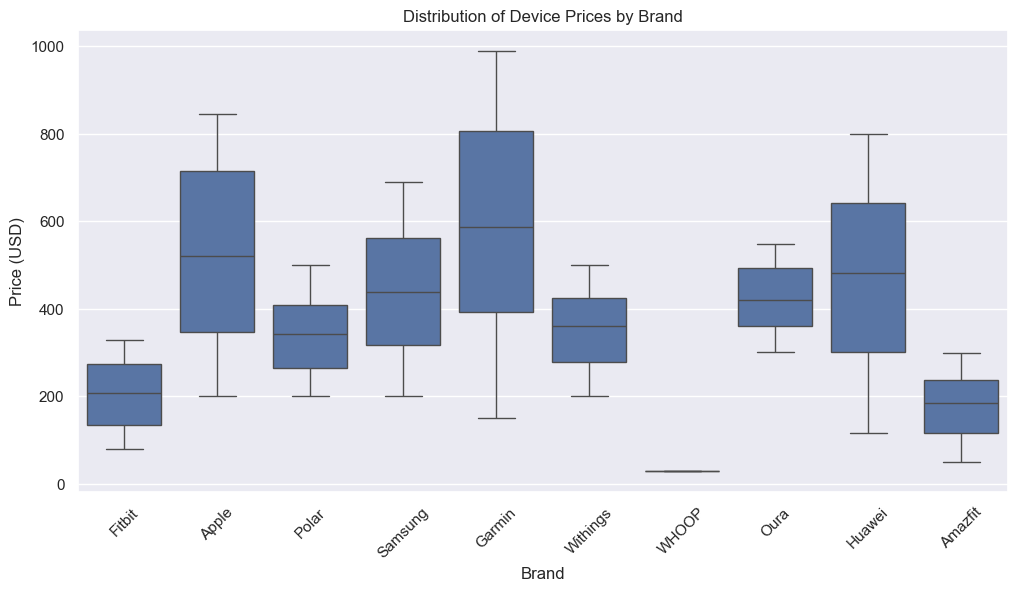

In [43]:
#boxplot comparing different brand  price distribution

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_wearables,
    x="Brand",
    y="Price_USD"
)

plt.title("Distribution of Device Prices by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.show()

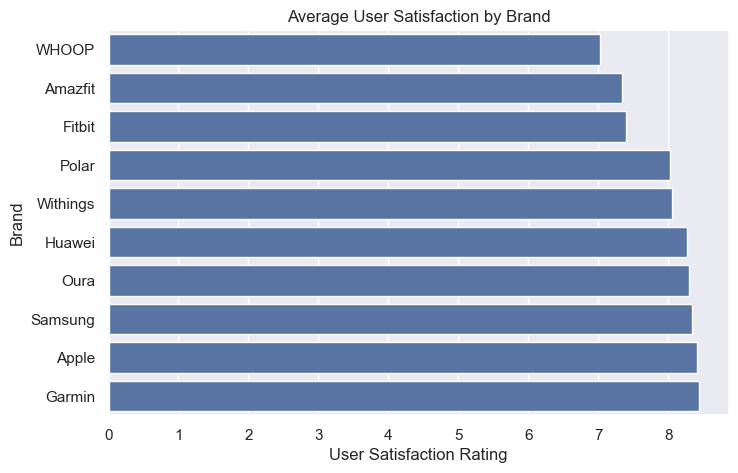

In [44]:
#correlation of satisfaction and the brand

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

brand_sat = df_wearables.groupby("Brand")["User_Satisfaction_Rating"].mean().sort_values()

sns.barplot(x=brand_sat.values, y=brand_sat.index)

plt.title("Average User Satisfaction by Brand")
plt.xlabel("User Satisfaction Rating")
plt.ylabel("Brand")
plt.show()

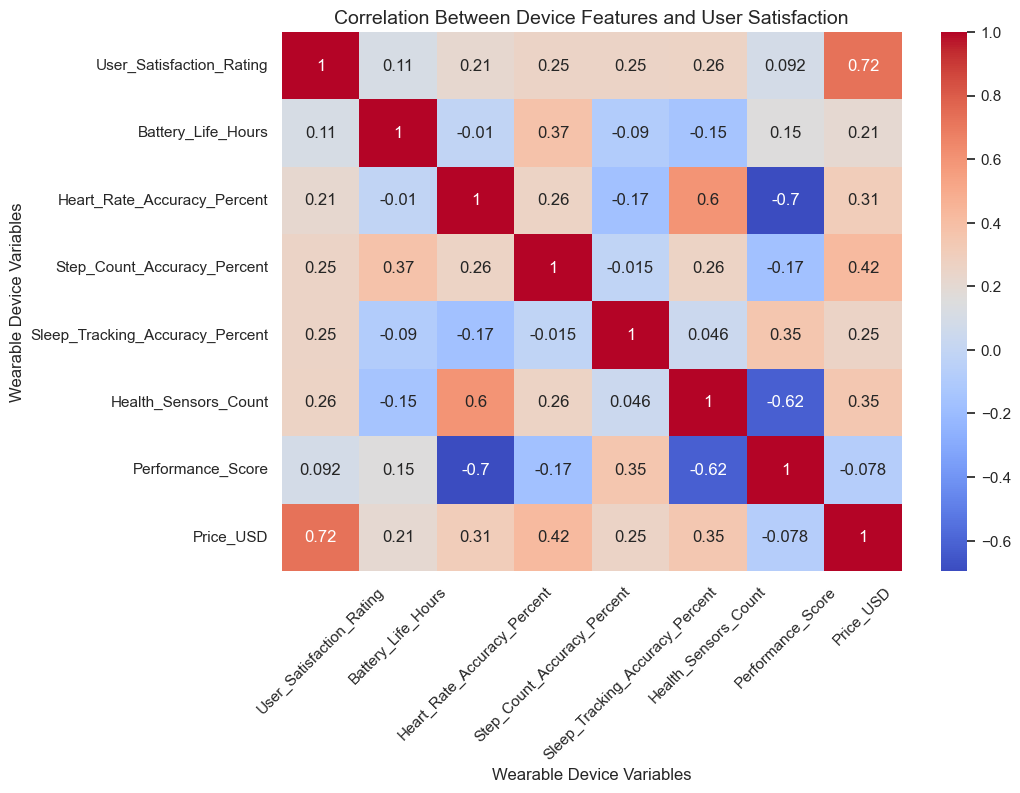

In [45]:
# effect of various features on the satisfaction (heatmap)
import matplotlib.pyplot as plt
import seaborn as sns

# Select relevant variables
correlation_data = df_wearables[[
    "User_Satisfaction_Rating",
    "Battery_Life_Hours",
    "Heart_Rate_Accuracy_Percent",
    "Step_Count_Accuracy_Percent",
    "Sleep_Tracking_Accuracy_Percent",
    "Health_Sensors_Count",
    "Performance_Score",
    "Price_USD"
]]

# Compute correlation matrix
correlation_matrix = correlation_data.corr()

# Create heatmap
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

# Titles and labels
plt.title(
    "Correlation Between Device Features and User Satisfaction",
    fontsize=14
)

plt.xlabel("Wearable Device Variables")
plt.ylabel("Wearable Device Variables")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()




In [46]:
#RQ 1. Checking the effect of price on the performance via linear regresisons

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Features and target
X = df_wearables[["Price_USD"]]
y = df_wearables["Performance_Score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("R² score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# Regression coefficient
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

R² score: -0.0063648356438081866
MAE: 3.92184753742395
Slope: -0.0020214444507073402
Intercept: 64.85384509944645


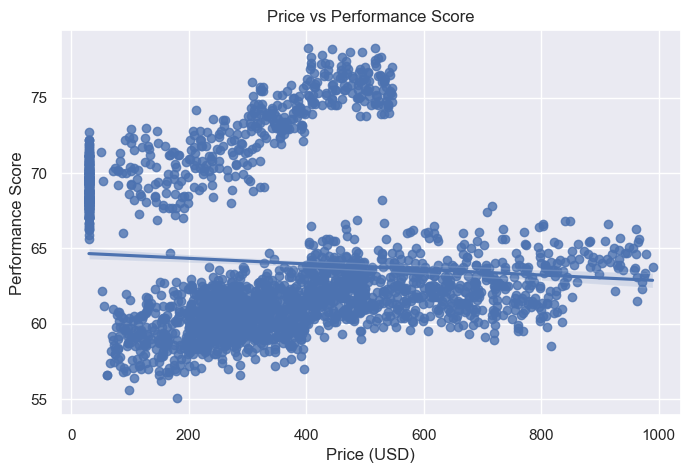

In [19]:
#RQ1. Scatterplot and regression line demonstrating the linear regression of price vs performance score


plt.figure(figsize=(8,5))

sns.regplot(
    data=df_wearables,
    x="Price_USD",
    y="Performance_Score"
)

plt.title("Price vs Performance Score")
plt.xlabel("Price (USD)")
plt.ylabel("Performance Score")

plt.show()

In [22]:
#RQ2. Checking the effect of different wearble features on the user satisfaction via Random Forest regression

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# Features
X = df_wearables[[
    "Price_USD",
    "Battery_Life_Days",
    "Heart_Rate_Accuracy_Percent",
    "Step_Count_Accuracy_Percent",
    "Sleep_Tracking_Accuracy_Percent",
    "GPS_Accuracy_Meters",
    "Health_Sensors_Count",
    "Performance_Score"
]]


# TARGET 

y = df_wearables["User_Satisfaction_Rating"]
X = X.fillna(X.mean())


# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Model

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)


# Predictions

y_pred = model.predict(X_test)

print("R² score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


# Evaluation

from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R² score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


# Feature importance

import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance)

R² score: 0.8852167518962588
MAE: 0.22168256194483335
R² score: 0.8852167518962588
MAE: 0.22168256194483335
                           feature  importance
0                        Price_USD    0.700209
7                Performance_Score    0.133442
1                Battery_Life_Days    0.039510
4  Sleep_Tracking_Accuracy_Percent    0.038263
5              GPS_Accuracy_Meters    0.029310
2      Heart_Rate_Accuracy_Percent    0.024599
3      Step_Count_Accuracy_Percent    0.021483
6             Health_Sensors_Count    0.013184


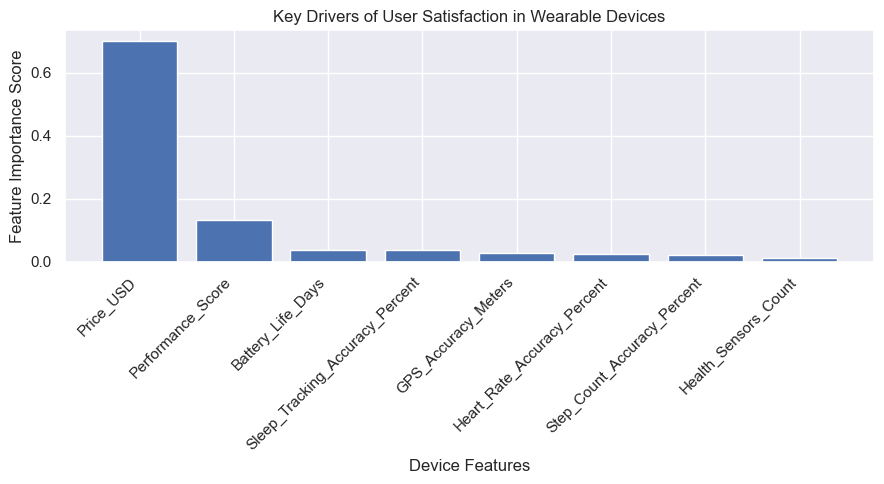

In [34]:
#RQ2. Visualising future importance via plot

import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.bar(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.title("Key Drivers of User Satisfaction in Wearable Devices")
plt.xlabel("Device Features")
plt.ylabel("Feature Importance Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [37]:
#RQ1. Export of raw data and results

#predictions on the effect of the price on the performance
rq1_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

rq1_results.to_csv("rq1_predictions.csv", index=False)

#model performance summary 

from sklearn.metrics import r2_score, mean_absolute_error

rq1_summary = pd.DataFrame({
    "Metric": ["R2", "MAE"],
    "Value": [
        r2_score(y_test, y_pred),
        mean_absolute_error(y_test, y_pred)
    ]
})

rq1_summary.to_csv("rq1_model_summary.csv", index=False)

# coefficients
rq1_coefficients = pd.DataFrame({
    "Feature": ["Price_USD"],
    "Coefficient": [model.coef_[0]],
    "Intercept": [model.intercept_]
})

rq1_coefficients.to_csv("rq1_coefficients.csv", index=False)

In [29]:
# RQ2. Export of raw data and results 


#feature importance in the satisfaction
feature_importance.to_csv("rq2_feature_importance.csv", index=False)
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})


#Model predictions
results.to_csv("rq2_predictions.csv", index=False)


#Model performance summary
summary = pd.DataFrame({
    "Metric": ["R2", "MAE"],
    "Value": [r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)]
})

summary.to_csv("rq2_model_summary.csv", index=False)


In [47]:
# A part where the Notebook connects to an API either for collecting data as the primary data source or as a supplementary data source, or e.g. for connecting to an LLM that is used for cleaning data or analyzing data

#connecting to Ollama

from openai import OpenAI

MODEL = "llama3.2"

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)


#creating API function
def ask_llm(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

#RQ2 interpretation

top_features_text = feature_importance.head(5).to_string()

prompt = f"""
You are a data analyst.

Explain the following feature importance results for user satisfaction in wearable devices.
Focus on business interpretation, not technical detail.

{top_features_text}
"""

print(ask_llm(prompt))



As a data analyst, I've analyzed the feature importance results for user satisfaction in wearable devices, and here's my interpretation:

**Key Insights:**

1. **Price**: User satisfaction is most closely linked to the price of the wearable device. This suggests that consumers are budget-conscious when it comes to purchasing wearables, and that higher prices can negatively impact their perceived value.
2. **Performance**: While performance is an important factor in user satisfaction (20% importance), it's not as strong a driver as price. This may indicate that consumers prioritize features like battery life and accuracy over raw performance metrics.

**Business Takeaways:**

* **Pricing strategy:** To differentiate our wearable device, consider offering competitive pricing without compromising on quality. If budget is a major concern for users, focus on providing better value through superior performance, user experience, or additional features.
* **Feature enhancements:** Given the mo

Conclusion

When it comes to the price of the wearable, it does not predict the performance score, which is supported by the linear regression model and the visualisation. The linear regression model value was close to 0 (-0.006 R²) score shows that price does not explain the variation in the performance score. Furthermore, the regression slope was also quite tiny and slightly negative, indicating no particular relationship between device price and objective performance. 

At the same time, the scatterplots demonstrated that the relationship between the price and performance depends on the device category. Thus, smart rings illustrate the highest performance scores (75-78) while having moderate prices compared to smart watches and the smartwatches and sport watches. Nevertheless, the most expensive smart rings have the highest performance score. 

Similarly, more fitness trackers demonstrate higher performance. The most widespread group of devices, such as smartwatches and sports watches have lower performance score (55-67). The cheapest fitness bands with a limited price range still have relatively high performance (65-73).

In terms of the wearables features' effect on the user satisfaction, price in USD turned out to have a strong positive effect on the satisfaction (0.72). It means that more expensive devices tend to elicit a positive effect on satisfaction. For example, the visual tool also showcases that the most expensive wearable brand Garmin, elicits more satisfaction compared to Fitbit, Amazfit and Whoop, with the lowest satisfaction. 

Among the technical features, the number of health sensors (0.26) as well as step count and sleep count accuracy (0.25) tend to have higher satisfaction ratings in contrast to battery life cycle (0.11). 

Similarly, the Random Forest model indicates that the price predicts the user satisfaction, accounting 70% of future importance. It is followed by the performance score, while technical accuracy metrics are less relevant. 

To conclude, the analysis demonstrated that the device category appears to be a more important determinant of performance score than price alone. At the same time, the user satisfaction appears to be more strongly associated with device price than with individual technical performance metrics.
